<a href="https://colab.research.google.com/github/clobos/Python_Tatiana_Ecologia_Aplicada/blob/main/prophet_brincando.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Quando faz sentido usar Prophet

- Séries com forte sazonalidade anual, semanal ou diária e algumas temporadas de histórico. [comunidadedeestatistica.com](https://comunidadedeestatistica.com.br/wp-content/uploads/2021/06/prophet-Kelly-pego.pdf)
- Dados com faltantes, outliers e possíveis mudanças de tendência (changepoints) ao longo do tempo. [translate.google](https://translate.google.com/translate?u=https%3A%2F%2Ffacebook.github.io%2Fprophet%2F&hl=pt&sl=en&tl=pt&client=srp)
- Aplicações típicas: demanda/vendas, tráfego em sites, consumo de energia, séries ambientais etc. [digitalocean](https://www.digitalocean.com/community/tutorials/a-guide-to-time-series-forecasting-with-prophet-in-python-3)

Um exemplo no seu contexto: previsão de produção diária de leite, consumo de energia em frigorífico ou fluxo de visitantes em parque.

## Instalação e ideia do modelo

- Instalação (versão atual no PyPI usa `prophet` em vez de `fbprophet`):  
  `pip install prophet`. [pypi](https://pypi.org/project/prophet/)
- A interface básica segue o padrão: criar o modelo, ajustar e prever. [machinelearningmastery](https://www.machinelearningmastery.com/time-series-forecasting-with-prophet-in-python/)
- Modelo aditivo:  
  \( y(t) = g(t) + s(t) + h(t) + \varepsilon_t \),  
  onde \(g(t)\) é tendência (possivelmente com changepoints), \(s(t)\) são sazonalidades (ano, semana, dia), \(h(t)\) são efeitos de feriados/eventos e \(\varepsilon_t\) é o erro. [machinelearningmastery](https://www.machinelearningmastery.com/time-series-forecasting-with-prophet-in-python/)

## Passo a passo mínimo em Python

Fluxo básico que você pode usar em aula ou projeto:

1. **Preparar o DataFrame**
   - Prophet exige um `pandas.DataFrame` com duas colunas:
     - `ds`: datas (tipo datetime).
     - `y`: valor da série (contínuo ou contagem). [pypi](https://pypi.org/project/prophet/)

2. **Ajustar o modelo**
   ```python
   from prophet import Prophet
   m = Prophet()               # pode configurar sazonalidade, crescimento etc.
   m.fit(df)                   # df com colunas 'ds' e 'y'
   ``` [pypi](https://pypi.org/project/prophet/)

3. **Criar datas futuras e prever**
   ```python
   future = m.make_future_dataframe(periods=365, freq='D')  # 365 dias à frente
   forecast = m.predict(future)
   ``` [pypi](https://pypi.org/project/prophet/)

4. **Inspecionar saídas**
   - `forecast['yhat']`: previsão pontual.  
   - `forecast['yhat_lower']`, `forecast['yhat_upper']`: intervalo de incerteza. [mode](https://mode.com/example-gallery/forecasting_prophet_python_cookbook/)

5. **Plot básico**
   ```python
   from prophet.plot import plot_plotly, plot_components_plotly
   fig = m.plot(forecast)              # matplotlib
   fig_components = m.plot_components(forecast)
   ``` [digitalocean](https://www.digitalocean.com/community/tutorials/a-guide-to-time-series-forecasting-with-prophet-in-python-3)

Os gráficos de componentes mostram separadamente tendência, sazonalidades e efeitos de feriados. [digitalocean](https://www.digitalocean.com/community/tutorials/a-guide-to-time-series-forecasting-with-prophet-in-python-3)

## Recursos em português e materiais didáticos

- Livro “Séries temporais com Prophet” (Casa do Código) com exemplos em Python e explicação de tendência, changepoints, sazonalidade, validação cruzada e tuning. [casadocodigo.com](https://www.casadocodigo.com.br/products/livro-series-temporais-prophet)
- Slides/tutoriais em português sobre Prophet destacando robustez a dados faltantes, outliers e sazonalidades múltiplas. [blog.dsacademy.com](https://blog.dsacademy.com.br/5-bibliotecas-python-para-analise-de-series-temporais/)
- Vídeos em português explicando passo a passo a aplicação do Prophet em Python focando em previsão de séries reais. [youtube](https://www.youtube.com/watch?v=nIoHj7ei2to)

Para usar em disciplina/apostila, você pode combinar:
- uma aula introdutória mostrando o modelo aditivo e a sintaxe mínima,  
- um exercício com dados de produção agro, clima ou vendas, pedindo ajuste, diagnóstico e discussão de componentes.

Se você quiser, posso montar um notebook-modelo em Python (estrutura de aula) com: import, preparação da série, ajuste de Prophet, análise de resíduos e comparação com um modelo ARIMA simples.

In [8]:
#!pip install prophet

In [3]:
import pandas as pd
import numpy as np

# Criando um DataFrame de exemplo para demonstrar o Prophet
dates = pd.date_range(start='2023-01-01', periods=100, freq='D')
y_values = np.random.rand(100) * 100 + np.sin(np.arange(100)/5) * 50 # Adicionando um padrão sazonal

df = pd.DataFrame({'ds': dates, 'y': y_values})

print("DataFrame 'df' criado:")
display(df.head())

DataFrame 'df' criado:


,ds,y
0,2023-01-01,85.531430
1,2023-01-02,75.415386
2,2023-01-03,63.900228
3,2023-01-04,53.433933
4,2023-01-05,110.454812


Este código utiliza a biblioteca Prophet para realizar previsões em séries temporais. Veja a explicação linha a linha:

from prophet import Prophet: Esta linha importa a

1. classe Prophet da biblioteca prophet, que é o primeiro passo para usar o modelo.

2. m = Prophet(): Aqui, uma nova instância do modelo Prophet é criada. É neste ponto que você poderia configurar parâmetros como sazonalidade (anual, diária), tipo de crescimento (linear, logístico) e feriados, embora neste exemplo esteja usando as configurações padrão.

3. m.fit(df): Esta é a etapa de treinamento do modelo. Ele ajusta o Prophet aos seus dados históricos, que devem estar em um DataFrame chamado df com duas colunas obrigatórias: 'ds' (para a data/timestamp) e 'y' (para o valor a ser previsto).

4. future = m.make_future_dataframe(periods=365, freq='D'): Esta linha cria um DataFrame contendo datas futuras para as quais você deseja fazer previsões. periods=365 indica que ele gerará 365 datas futuras, e freq='D' especifica que a frequência dessas datas é diária.

5. forecast = m.predict(future): Finalmente, esta linha usa o modelo treinado (m) para gerar as previsões para as datas futuras criadas na etapa anterior. O resultado (forecast) é um DataFrame que inclui as previsões ('yhat') e seus respectivos intervalos de incerteza.

In [5]:
from prophet import Prophet
m = Prophet()               # pode configurar sazonalidade, crescimento etc.
m.fit(df)                   # df com colunas 'ds' e 'y'
future = m.make_future_dataframe(periods=365, freq='D')  # 365 dias à frente
forecast = m.predict(future)

INFO:prophet:Disabling yearly seasonality. Run prophet with yearly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [20]:
from prophet.plot import plot_plotly, plot_components_plotly
import matplotlib.pyplot as plt # Importar matplotlib para exibir as figuras separadamente





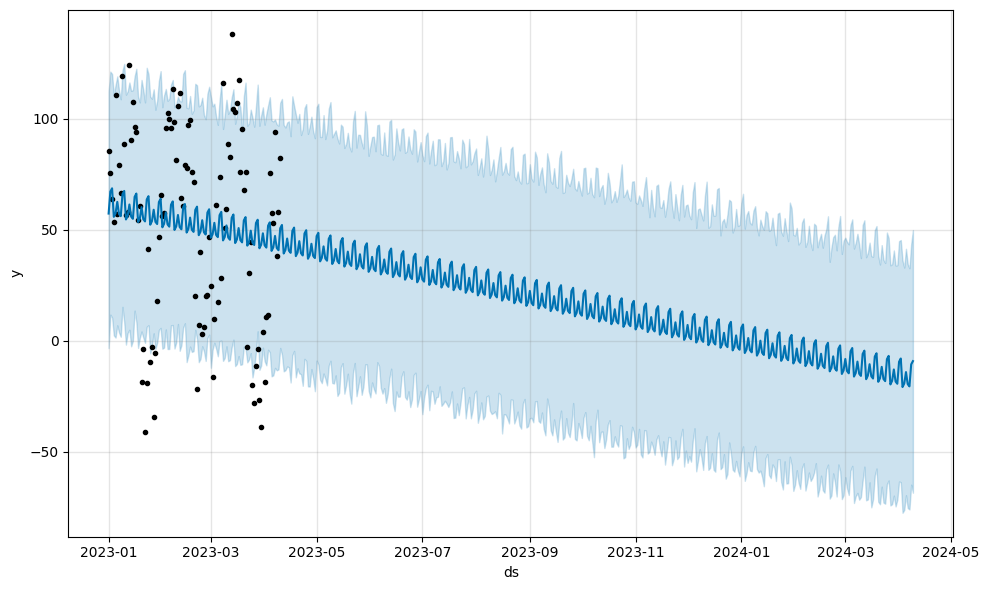

In [22]:

fig = m.plot(forecast)              # matplotlib
plt.show(fig) # Exibe o gráfico da previsão principal


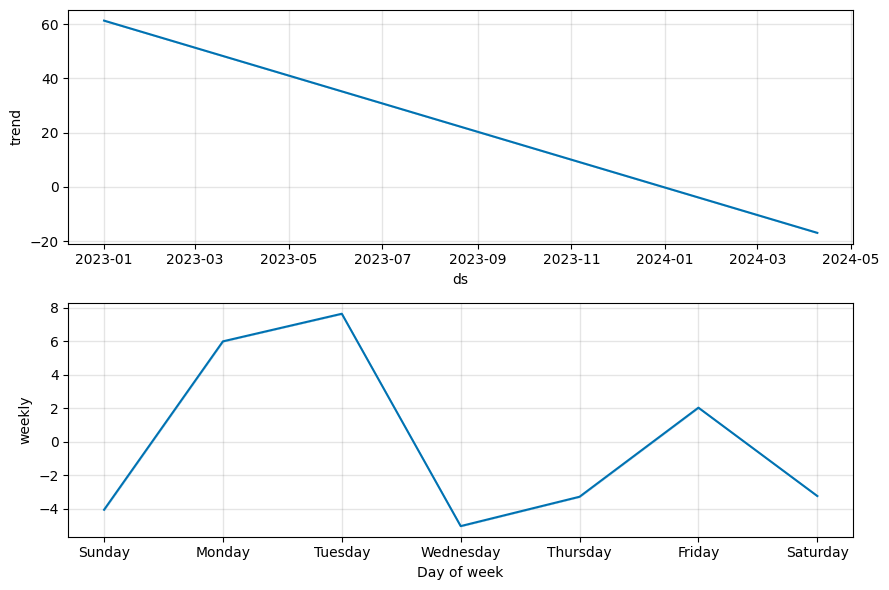

In [23]:
fig_components = m.plot_components(forecast)
plt.show(fig_components) # Exibe o gráfico dos componentes

O Prophet não faz uma separação automática de dados em conjuntos de treinamento e teste da mesma forma que muitos algoritmos de aprendizado de máquina supervisionado. Em vez disso, você fornece o histórico completo da série temporal para o Prophet treinar (m.fit(df)).

No entanto, para avaliar o desempenho do modelo em dados 'não vistos' (que é o objetivo de uma divisão entre treino e teste), o Prophet oferece ferramentas robustas para validação cruzada de séries temporais.

Funciona assim:

1. Treinamento: Você treina o modelo Prophet com todo o seu conjunto de dados históricos.

2. Validação Cruzada: O Prophet possui a função cross_validation que simula a previsão em diferentes pontos no tempo, utilizando uma janela deslizante de dados históricos. Ele corta seu histórico em pontos específicos, treina o modelo até aquele ponto e, em seguida, faz previsões para um período futuro. Isso é repetido várias vezes, movendo o ponto de corte para a frente.

3. Avaliação: Os resultados da validação cruzada (performance_metrics) podem ser usados para calcular métricas de erro como RMSE, MAE, MAPE, etc., comparando as previsões com os valores reais que foram "retidos" em cada simulação.

## Validação Cruzada com Prophet

Para validar o modelo e entender como ele se comportaria em dados não vistos, podemos usar a funcionalidade de validação cruzada do Prophet. Esta abordagem simula a previsão em diferentes pontos no tempo, re-treinando o modelo com janelas de dados históricos e prevendo um horizonte futuro.

Depois de executar a validação cruzada, podemos analisar as métricas de desempenho para avaliar a precisão do modelo.

In [7]:
from prophet.diagnostics import cross_validation, performance_metrics
import pandas as pd

# Realiza a validação cruzada do modelo Prophet
# 'initial': Período inicial de treinamento. Aqui, usamos 70 dias ('70 days').
#            O modelo será treinado com os primeiros 70 dias de dados.
# 'period': Frequência com que o ponto de corte (cut-off) é movido. Aqui, a cada 30 dias ('30 days').
#           O modelo será re-treinado a cada 30 dias adicionais de dados.
# 'horizon': Período de previsão para cada teste. Aqui, prevê os próximos 10 dias ('10 days').
#            Para cada ponto de corte, o modelo prevê os 10 dias seguintes.
df_cv = cross_validation(
    m, initial='70 days', period='30 days', horizon = '10 days'
)

print("DataFrame da validação cruzada (df_cv) criado:")
display(df_cv.head())

# Calcula as métricas de desempenho com base nos resultados da validação cruzada
# Aqui, estamos avaliando o desempenho para o horizonte de 10 dias.
df_p = performance_metrics(df_cv, metrics=['mse', 'rmse', 'mae', 'mape', 'mdape'])

print("\nMétricas de desempenho (df_p) calculadas:")
display(df_p.head())

# Opcional: Você pode plotar as métricas de desempenho para visualizar a performance
# from prophet.plot import plot_cross_validation_metric
# fig_mse = plot_cross_validation_metric(df_cv, metric='mse')
# fig_rmse = plot_cross_validation_metric(df_cv, metric='rmse')
# fig_mae = plot_cross_validation_metric(df_cv, metric='mae')

INFO:prophet:Making 1 forecasts with cutoffs between 2023-03-31 00:00:00 and 2023-03-31 00:00:00


  0%|          | 0/1 [00:00<?, ?it/s]

DataFrame da validação cruzada (df_cv) criado:


,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2023-04-01,37.965889,-19.431739,90.995218,-18.805033,2023-03-31
1,2023-04-02,32.160515,-24.235779,88.008997,10.819301,2023-03-31
2,2023-04-03,41.771229,-15.572507,100.022983,11.368472,2023-03-31
3,2023-04-04,41.142289,-20.767471,97.047955,75.708921,2023-03-31
4,2023-04-05,28.270434,-30.057010,82.985510,57.328366,2023-03-31



Métricas de desempenho (df_p) calculadas:


,horizon,mse,rmse,mae,mape,mdape
0,1 days,3222.937605,56.770922,56.770922,3.018922,3.018922
1,2 days,455.447398,21.341214,21.341214,1.972513,1.972513
2,3 days,924.327660,30.402757,30.402757,2.674305,2.674305
3,4 days,1194.852025,34.566632,34.566632,0.456573,0.456573
4,5 days,844.363414,29.057932,29.057932,0.506868,0.506868


xcelente! A validação cruzada do modelo Prophet foi concluída com sucesso.

Você pode ver os primeiros resultados no DataFrame da validação cruzada (df_cv):

* ds: A data para a qual a previsão foi feita.
* yhat: O valor previsto pelo modelo.
* yhat_lower e yhat_upper: Os limites inferior e superior do intervalo de confiança da previsão.
* y: O valor real observado.
* cutoff: A data de corte usada para o treinamento do modelo para aquela previsão específica.

E também as Métricas de desempenho (df_p):

* horizon: O horizonte de previsão em dias.
* mse: Erro quadrático médio.
* rmse: Raiz do erro quadrático médio.
* mae: Erro absoluto médio.
* mape: Erro percentual absoluto médio.
* mdape: Erro percentual absoluto mediano.

Estas métricas permitem avaliar o quão bem o seu modelo está performando em dados que ele não 'viu' durante o treinamento inicial, simulando diferentes cenários de previsão.

## Lidando com Dados Faltantes no Prophet

O Prophet é conhecido por sua robustez a dados faltantes. Ele pode interpolar valores ausentes de forma inteligente ao ajustar o modelo. Vamos demonstrar isso criando uma série temporal sintética, introduzindo diferentes percentagens de dados faltantes e observando como o Prophet se comporta.

### 1. Geração da Série Temporal Base

In [9]:
import pandas as pd
import numpy as np
from prophet import Prophet
import matplotlib.pyplot as plt
import seaborn as sns

# Gerar uma série temporal sintética de 2012 a 2022
# Usaremos um período mais longo (2012-2022) para ter dados suficientes para prever até 2030.
dates_base = pd.date_range(start='2012-01-01', end='2022-12-31', freq='D')

# Criar valores com uma tendência, sazonalidade e ruído
trend = np.linspace(0, 100, len(dates_base))
seasonality = 20 * np.sin(np.arange(len(dates_base)) * 2 * np.pi / 365) # Sazonalidade anual
noise = np.random.normal(0, 5, len(dates_base))
y_base = trend + seasonality + noise

df_base = pd.DataFrame({'ds': dates_base, 'y': y_base})

print("Série Temporal Base criada (primeiras 5 linhas):")
display(df_base.head())

Série Temporal Base criada (primeiras 5 linhas):


,ds,y
0,2012-01-01,2.107889
1,2012-01-02,6.175293
2,2012-01-03,-0.654757
3,2012-01-04,4.614284
4,2012-01-05,4.606141


### 2. Introdução de Dados Faltantes

Agora, vamos criar três cópias da nossa série temporal e introduzir 10%, 20% e 30% de dados faltantes (NaN) aleatoriamente.

In [10]:
def introduce_missing_data(df, percentage):
    df_missing = df.copy()
    num_missing = int(len(df) * percentage)
    missing_indices = np.random.choice(df.index, num_missing, replace=False)
    df_missing.loc[missing_indices, 'y'] = np.nan
    return df_missing



DataFrame com 10% de faltantes (primeiras 5 linhas):


,ds,y
0,2012-01-01,2.107889
1,2012-01-02,6.175293
2,2012-01-03,-0.654757
3,2012-01-04,4.614284
4,2012-01-05,4.606141



DataFrame com 20% de faltantes (primeiras 5 linhas):


,ds,y
0,2012-01-01,2.107889
1,2012-01-02,NaN
2,2012-01-03,-0.654757
3,2012-01-04,NaN
4,2012-01-05,NaN



DataFrame com 30% de faltantes (primeiras 5 linhas):


,ds,y
0,2012-01-01,2.107889
1,2012-01-02,6.175293
2,2012-01-03,-0.654757
3,2012-01-04,NaN
4,2012-01-05,4.606141


In [ ]:
# Cenário com 10% de dados faltantes
df_10_missing = introduce_missing_data(df_base, 0.10)
print("DataFrame com 10% de faltantes (primeiras 5 linhas):")
display(df_10_missing.head())


In [ ]:

# Cenário com 20% de dados faltantes
df_20_missing = introduce_missing_data(df_base, 0.20)
print("\nDataFrame com 20% de faltantes (primeiras 5 linhas):")
display(df_20_missing.head())



In [ ]:
# Cenário com 30% de dados faltantes
df_30_missing = introduce_missing_data(df_base, 0.30)
print("\nDataFrame com 30% de faltantes (primeiras 5 linhas):")
display(df_30_missing.head())

### 3. Treinamento do Prophet e Previsão com Dados Faltantes

O Prophet lida com dados faltantes automaticamente. Não precisamos fazer nenhuma etapa de pré-processamento para preencher os valores ausentes (`NaN`). Basta passar o DataFrame com os `NaN`s para o `fit()`.

Vamos treinar um modelo para cada cenário de dados faltantes e prever até 2030.

In [13]:
def train_and_forecast_prophet(df_with_missing, df_name):
    print(f"\n--- Processando {df_name} ---")
    m = Prophet(yearly_seasonality=True, daily_seasonality=False) # Adicionar sazonalidade anual explícita
    m.fit(df_with_missing.dropna(subset=['y'])) # Opcional: remover NaNs explicitamente, embora Prophet faça isso internamente

    # Criar datas futuras até 2030
    end_date = pd.to_datetime('2030-12-31')
    last_date = df_with_missing['ds'].max()
    periods_to_forecast = (end_date - last_date).days + 1 # +1 para incluir o dia final de 2030
    future = m.make_future_dataframe(periods=periods_to_forecast, freq='D')

    forecast = m.predict(future)
    return m, forecast

# Modelos e previsões para cada cenário
m_10, forecast_10 = train_and_forecast_prophet(df_10_missing, '10% Missing Data')
m_20, forecast_20 = train_and_forecast_prophet(df_20_missing, '20% Missing Data')
m_30, forecast_30 = train_and_forecast_prophet(df_30_missing, '30% Missing Data')

print("Previsões concluídas para todos os cenários.")

display(forecast_10.head())


--- Processando 10% Missing Data ---

--- Processando 20% Missing Data ---

--- Processando 30% Missing Data ---
Previsões concluídas para todos os cenários.


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2012-01-01,0.485486,-4.553436,8.202783,0.485486,0.485486,0.716959,0.716959,0.716959,0.344034,0.344034,0.344034,0.372925,0.372925,0.372925,0.0,0.0,0.0,1.202445
1,2012-01-02,0.509617,-5.174863,7.619512,0.509617,0.509617,0.758683,0.758683,0.758683,0.097322,0.097322,0.097322,0.661361,0.661361,0.661361,0.0,0.0,0.0,1.268300
2,2012-01-03,0.533749,-5.296308,8.133348,0.533749,0.533749,0.921543,0.921543,0.921543,-0.018896,-0.018896,-0.018896,0.940439,0.940439,0.940439,0.0,0.0,0.0,1.455292
3,2012-01-04,0.557881,-3.839707,8.663410,0.557881,0.557881,1.437497,1.437497,1.437497,0.226177,0.226177,0.226177,1.211319,1.211319,1.211319,0.0,0.0,0.0,1.995378
4,2012-01-05,0.582013,-4.392647,8.578700,0.582013,0.582013,1.501617,1.501617,1.501617,0.026203,0.026203,0.026203,1.475415,1.475415,1.475415,0.0,0.0,0.0,2.083631


### 4. Visualização dos Resultados

Vamos plotar as previsões para cada cenário de dados faltantes. Você poderá observar como o Prophet preenche os gaps e mantém a tendência e sazonalidade mesmo com uma quantidade considerável de dados ausentes.

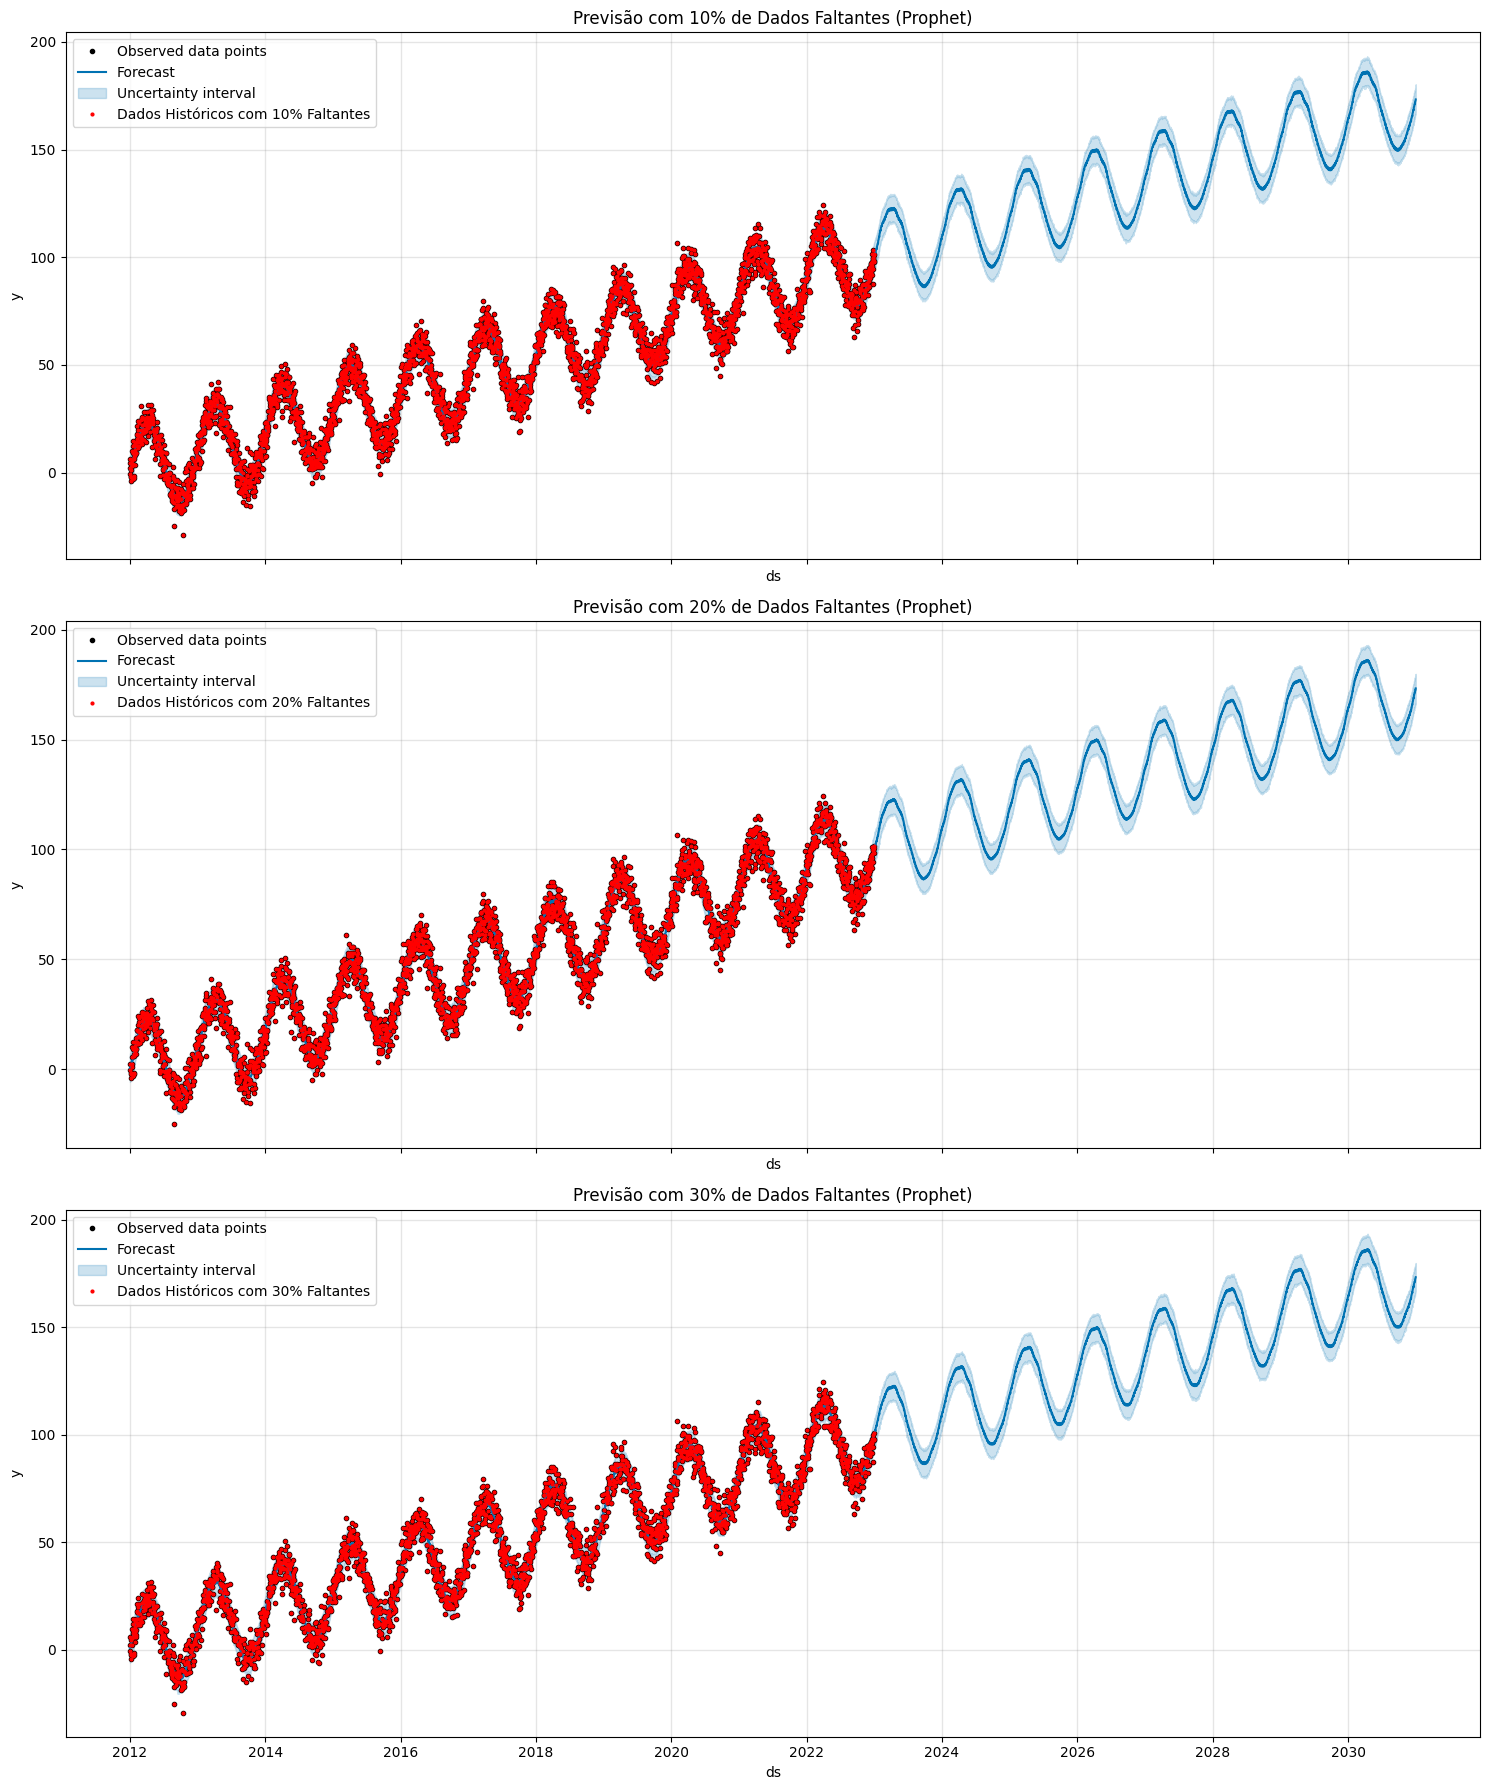

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(15, 18), sharex=True)

# 10% Faltantes
m_10.plot(forecast_10, ax=axes[0])
axes[0].plot(df_10_missing['ds'], df_10_missing['y'], 'o', markersize=2, color='red', label='Dados Históricos com 10% Faltantes')
axes[0].set_title('Previsão com 10% de Dados Faltantes (Prophet)')
axes[0].legend()

# 20% Faltantes
m_20.plot(forecast_20, ax=axes[1])
axes[1].plot(df_20_missing['ds'], df_20_missing['y'], 'o', markersize=2, color='red', label='Dados Históricos com 20% Faltantes')
axes[1].set_title('Previsão com 20% de Dados Faltantes (Prophet)')
axes[1].legend()

# 30% Faltantes
m_30.plot(forecast_30, ax=axes[2])
axes[2].plot(df_30_missing['ds'], df_30_missing['y'], 'o', markersize=2, color='red', label='Dados Históricos com 30% Faltantes')
axes[2].set_title('Previsão com 30% de Dados Faltantes (Prophet)')
axes[2].legend()

plt.tight_layout()
plt.show()